
# Analise de Produtos Agricolas: solo, clima e modelos preditivos

**Nome:** preencha seu nome completo  
**RM:** preencha seu RM  
**Fase/Capitulo:** Fase 3 - Capitulo 10

Este notebook analisa a base `produtos_agricolas.csv`, descreve os principais padroes de solo e clima, estima perfis ideais por cultura e compara cinco algoritmos de classificacao para prever a cultura mais adequada a partir das caracteristicas informadas.



## Objetivos do trabalho

1. Realizar uma analise exploratoria da base.
2. Produzir uma analise descritiva com visualizacoes e achados principais.
3. Estimar um perfil geral de solo/clima e comparar tres culturas escolhidas: arroz, milho e cafe.
4. Treinar cinco modelos preditivos diferentes e comparar a performance com metricas adequadas para classificacao multiclasse.
5. Discutir conclusoes, pontos fortes e limitacoes.



## 1. Preparacao do ambiente e carregamento da base

A variavel `label` sera tratada como alvo do problema de classificacao. As demais variaveis numericas representam as condicoes de solo e clima usadas como entrada dos modelos.


In [1]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

RANDOM_STATE = 42
DATA_PATH = Path("produtos_agricolas.csv")
FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Arquivo nao encontrado: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df = df.rename(columns={"pH": "ph", "PH": "ph"})

missing_cols = sorted(set(FEATURES + ["label"]) - set(df.columns))
if missing_cols:
    raise ValueError(f"Colunas ausentes na base: {missing_cols}")

df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



## 2. Conhecendo a estrutura dos dados

Antes de visualizar padroes, vale conferir tamanho da base, tipos das colunas, valores ausentes e duplicidades. Isso evita treinar modelos sobre dados inconsistentes sem perceber.


In [2]:

resumo_base = pd.DataFrame({
    "indicador": ["linhas", "colunas", "culturas distintas", "variaveis preditoras", "linhas duplicadas"],
    "valor": [df.shape[0], df.shape[1], df["label"].nunique(), len(FEATURES), int(df.duplicated().sum())],
})

diagnostico_colunas = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_%": (df.isna().mean() * 100).round(2),
})

display(resumo_base)
display(diagnostico_colunas)


,indicador,valor
0,linhas,2200
1,colunas,8
2,culturas distintas,22
3,variaveis preditoras,7
4,linhas duplicadas,0


,tipo,nulos,nulos_%
N,int64,0,0.0
P,int64,0,0.0
K,int64,0,0.0
temperature,float64,0,0.0
humidity,float64,0,0.0
ph,float64,0,0.0
rainfall,float64,0,0.0
label,str,0,0.0


In [3]:

estatisticas = df[FEATURES].describe().T.round(2)
distribuicao_culturas = (
    df["label"].value_counts()
    .rename_axis("cultura")
    .reset_index(name="quantidade")
    .assign(percentual=lambda x: (x["quantidade"] / len(df) * 100).round(2))
    .sort_values("cultura")
)

display(estatisticas)
display(distribuicao_culturas.head(10))
print(f"Total de culturas: {df['label'].nunique()}")


,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.55,36.92,0.00,21.00,37.00,84.25,140.00
P,2200.0,53.36,32.99,5.00,28.00,51.00,68.00,145.00
K,2200.0,48.15,50.65,5.00,20.00,32.00,49.00,205.00
temperature,2200.0,25.62,5.06,8.83,22.77,25.60,28.56,43.68
humidity,2200.0,71.48,22.26,14.26,60.26,80.47,89.95,99.98
ph,2200.0,6.47,0.77,3.50,5.97,6.43,6.92,9.94
rainfall,2200.0,103.46,54.96,20.21,64.55,94.87,124.27,298.56


,cultura,quantidade,percentual
15,apple,100,4.55
10,banana,100,4.55
7,blackgram,100,4.55
2,chickpea,100,4.55
18,coconut,100,4.55
21,coffee,100,4.55
19,cotton,100,4.55
12,grapes,100,4.55
20,jute,100,4.55
3,kidneybeans,100,4.55


Total de culturas: 22



## 3. Analise exploratoria e descritiva

Os graficos abaixo mostram distribuicao das culturas, comportamento das variaveis numericas, correlacoes e diferencas de solo/clima entre os tipos de cultura. Essa etapa ajuda a entender quais atributos parecem mais separadores antes da modelagem.


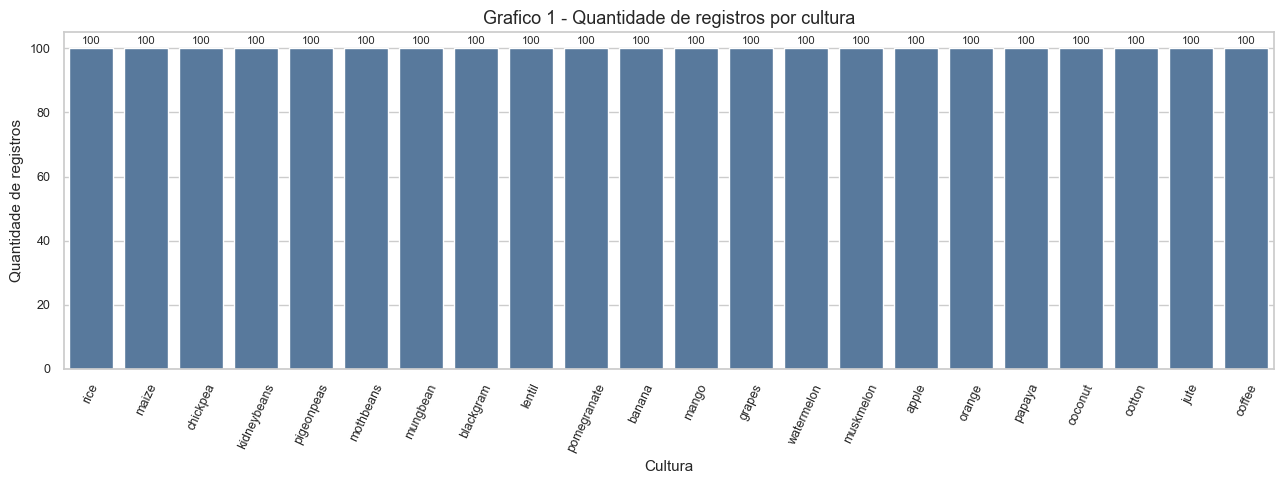

In [4]:

# Grafico 1 - Distribuicao das culturas
counts = df["label"].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(x=counts.index, y=counts.values, ax=ax, color="#4c78a8")
ax.set_title("Grafico 1 - Quantidade de registros por cultura")
ax.set_xlabel("Cultura")
ax.set_ylabel("Quantidade de registros")
ax.tick_params(axis="x", rotation=65)
ax.bar_label(ax.containers[0], fontsize=8, padding=2)
plt.tight_layout()
plt.show()


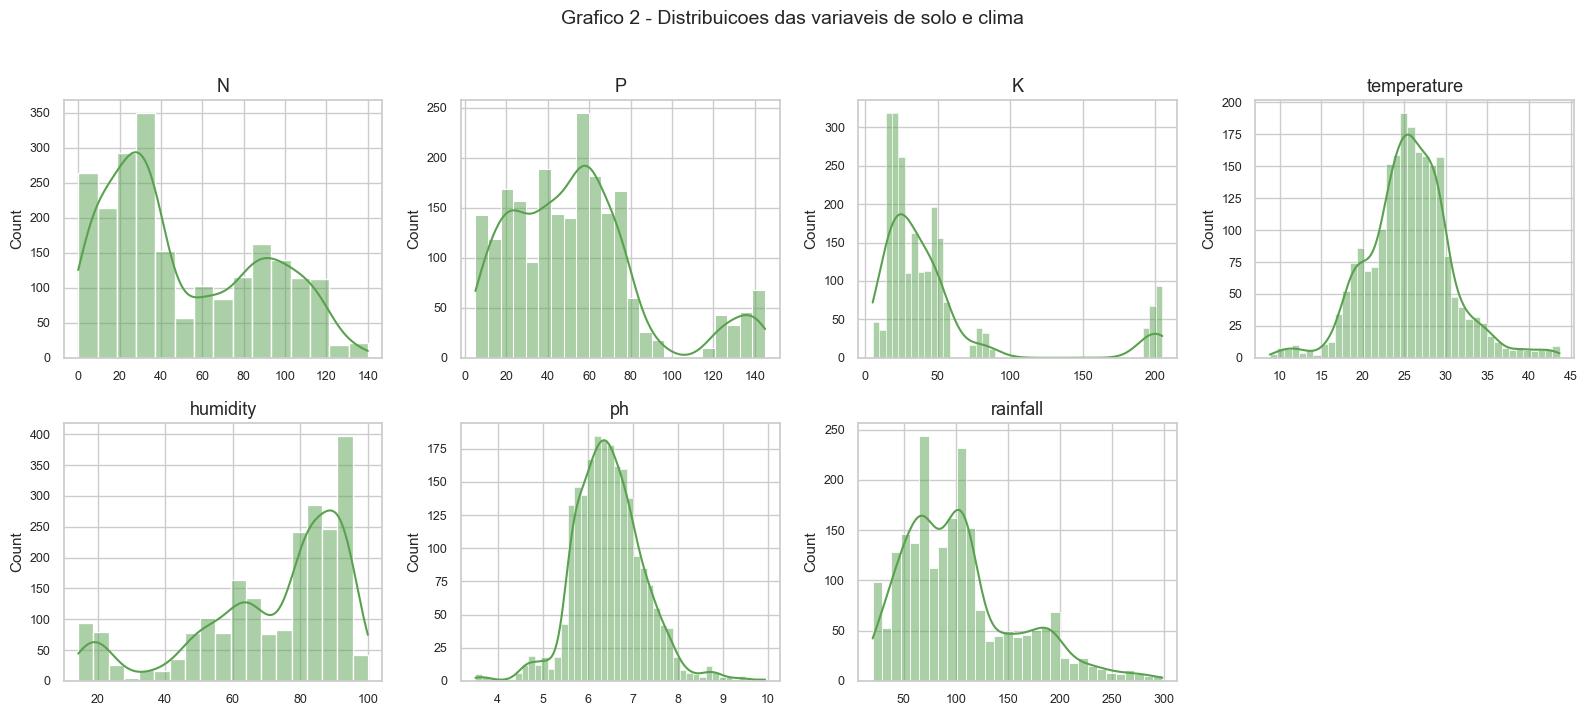

In [5]:

# Grafico 2 - Distribuicao das variaveis numericas
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()
for i, col in enumerate(FEATURES):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#59a14f")
    axes[i].set_title(col)
    axes[i].set_xlabel("")
axes[-1].axis("off")
fig.suptitle("Grafico 2 - Distribuicoes das variaveis de solo e clima", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


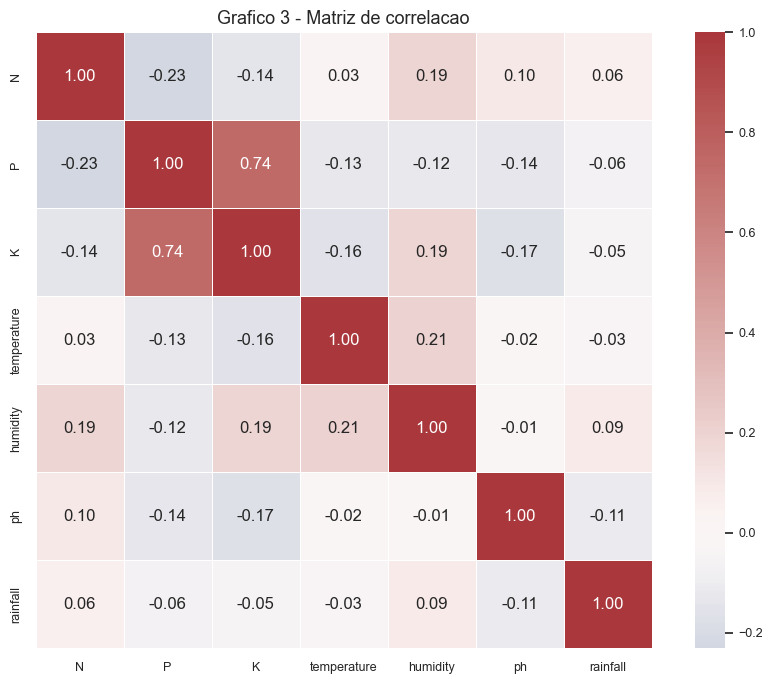

In [6]:

# Grafico 3 - Correlacao entre variaveis numericas
corr = df[FEATURES].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Grafico 3 - Matriz de correlacao")
plt.tight_layout()
plt.show()


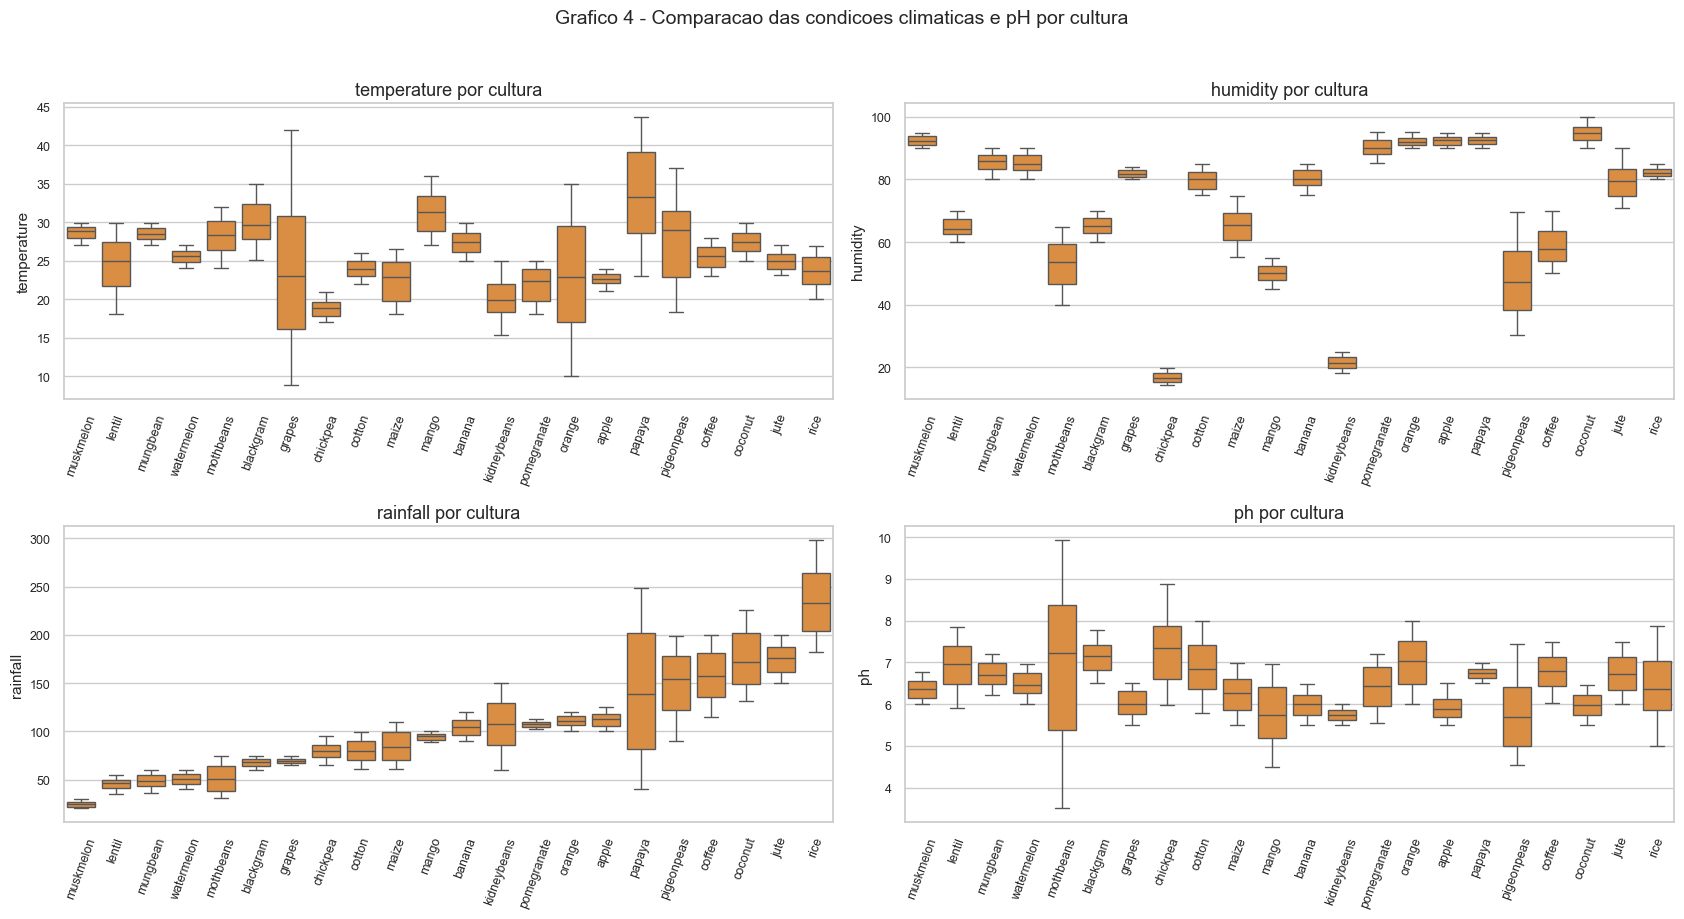

In [7]:

# Grafico 4 - Variaveis climaticas por cultura
climate_cols = ["temperature", "humidity", "rainfall", "ph"]
order = df.groupby("label")["rainfall"].median().sort_values().index
fig, axes = plt.subplots(2, 2, figsize=(17, 9))
for ax, col in zip(axes.ravel(), climate_cols):
    sns.boxplot(data=df, x="label", y=col, order=order, ax=ax, color="#f28e2b", showfliers=False)
    ax.set_title(f"{col} por cultura")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=70)
fig.suptitle("Grafico 4 - Comparacao das condicoes climaticas e pH por cultura", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


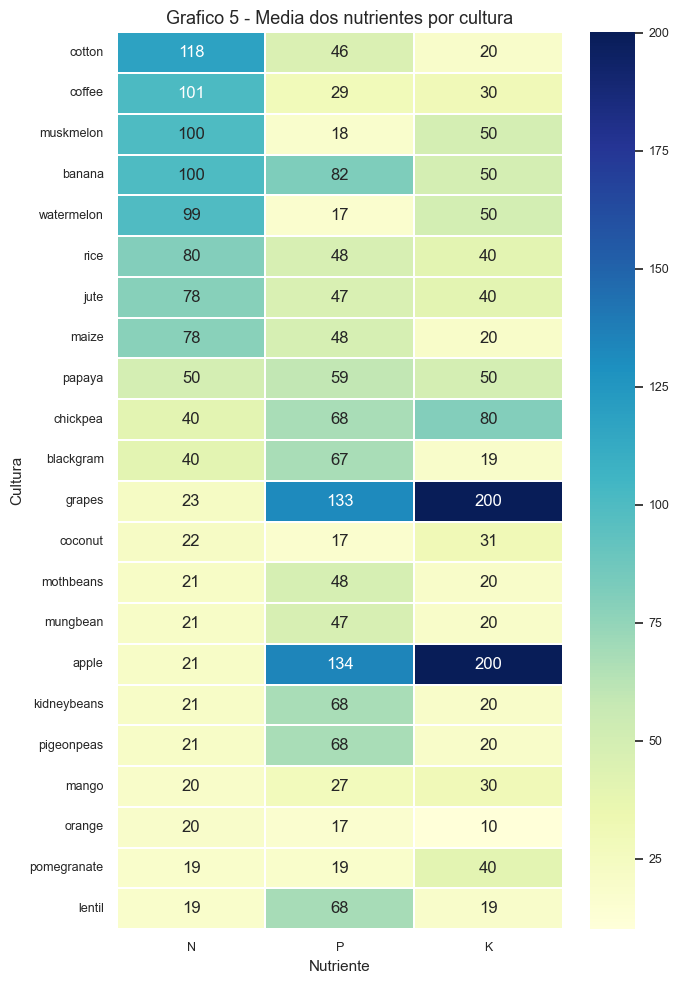

In [8]:

# Grafico 5 - Medias dos nutrientes N, P e K por cultura
nutrient_mean = df.groupby("label")[["N", "P", "K"]].mean().sort_values("N", ascending=False)
fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(nutrient_mean, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.3, ax=ax)
ax.set_title("Grafico 5 - Media dos nutrientes por cultura")
ax.set_xlabel("Nutriente")
ax.set_ylabel("Cultura")
plt.tight_layout()
plt.show()


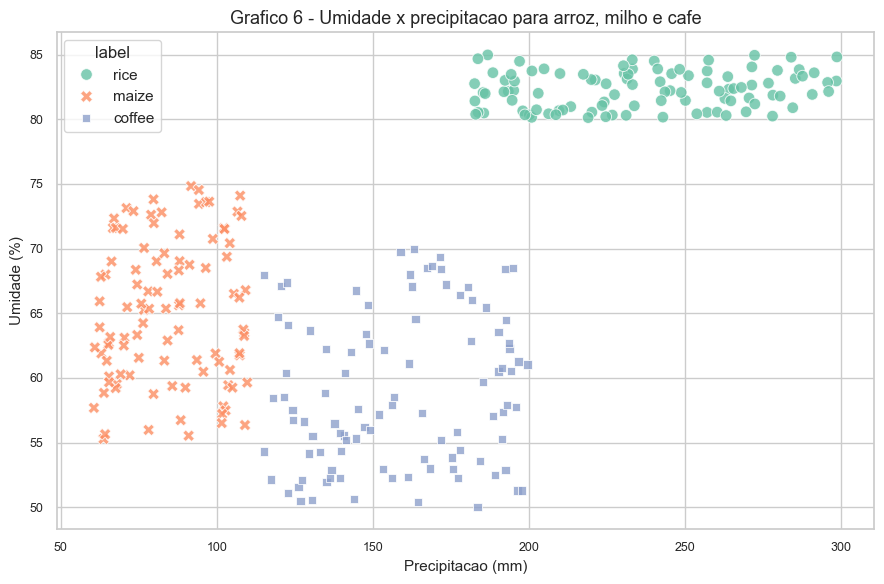

In [9]:

# Grafico 6 - Relacao entre umidade e precipitacao para culturas escolhidas
culturas_escolhidas = ["rice", "maize", "coffee"]
subset_escolhidas = df[df["label"].isin(culturas_escolhidas)]
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=subset_escolhidas,
    x="rainfall",
    y="humidity",
    hue="label",
    style="label",
    s=70,
    alpha=0.8,
    ax=ax,
)
ax.set_title("Grafico 6 - Umidade x precipitacao para arroz, milho e cafe")
ax.set_xlabel("Precipitacao (mm)")
ax.set_ylabel("Umidade (%)")
plt.tight_layout()
plt.show()


In [10]:

# Sintese automatizada dos achados exploratorios
upper_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_corr = upper_corr.reindex(upper_corr.abs().sort_values(ascending=False).index).head(3)
label_counts = df["label"].value_counts()
mais_chuvosa = df.groupby("label")["rainfall"].mean().idxmax()
menos_chuvosa = df.groupby("label")["rainfall"].mean().idxmin()
maior_umidade = df.groupby("label")["humidity"].mean().idxmax()
mais_quente = df.groupby("label")["temperature"].mean().idxmax()
mais_potassio = df.groupby("label")["K"].mean().idxmax()

corr_text = "; ".join([f"{a} x {b}: {v:.2f}" for (a, b), v in top_corr.items()])
balance_note = "balanceada" if label_counts.nunique() == 1 else "nao balanceada"

display(Markdown(f"""
### Principais achados da EDA

- A base possui **{len(df):,} registros**, **{df['label'].nunique()} culturas** e esta **{balance_note}** em relacao a quantidade de exemplos por cultura.
- Nao foram observados valores ausentes nas colunas usadas na modelagem, o que reduz a necessidade de imputacao.
- As maiores correlacoes lineares entre preditores foram: **{corr_text}**. Mesmo assim, nenhuma delas elimina a necessidade das demais variaveis, porque o alvo e multiclasse e os padroes por cultura sao combinacoes de solo e clima.
- Em media, a cultura com maior precipitacao foi **{mais_chuvosa}**, enquanto a menor media de precipitacao apareceu em **{menos_chuvosa}**.
- A maior umidade media ocorreu em **{maior_umidade}**, a maior temperatura media em **{mais_quente}** e a maior media de potassio em **{mais_potassio}**.
"""))



### Principais achados da EDA

- A base possui **2,200 registros**, **22 culturas** e esta **balanceada** em relacao a quantidade de exemplos por cultura.
- Nao foram observados valores ausentes nas colunas usadas na modelagem, o que reduz a necessidade de imputacao.
- As maiores correlacoes lineares entre preditores foram: **P x K: 0.74; N x P: -0.23; temperature x humidity: 0.21**. Mesmo assim, nenhuma delas elimina a necessidade das demais variaveis, porque o alvo e multiclasse e os padroes por cultura sao combinacoes de solo e clima.
- Em media, a cultura com maior precipitacao foi **rice**, enquanto a menor media de precipitacao apareceu em **muskmelon**.
- A maior umidade media ocorreu em **coconut**, a maior temperatura media em **papaya** e a maior media de potassio em **grapes**.



## 4. Perfil ideal de solo e clima

Como cada cultura tem necessidades diferentes, nao existe um unico solo/clima ideal para todas as plantacoes. Para cumprir a comparacao de forma objetiva, este trabalho usa dois niveis de perfil:

- **Perfil geral da base:** media, mediana e dispersao das condicoes observadas em todos os registros.
- **Perfil especifico por cultura:** media das variaveis dentro de cada `label`, interpretada como o centro das condicoes em que aquela cultura aparece como recomendada.

Para comparar arroz, milho e cafe com o perfil geral, tambem uso diferencas padronizadas: valores positivos indicam que a cultura fica acima da media geral da base naquela variavel; valores negativos indicam que fica abaixo.


In [11]:

perfil_geral = df[FEATURES].agg(["mean", "median", "std", "min", "max"]).T.round(2)
perfil_geral.columns = ["media", "mediana", "desvio_padrao", "minimo", "maximo"]
display(perfil_geral)


,media,mediana,desvio_padrao,minimo,maximo
N,50.55,37.00,36.92,0.00,140.00
P,53.36,51.00,32.99,5.00,145.00
K,48.15,32.00,50.65,5.00,205.00
temperature,25.62,25.60,5.06,8.83,43.68
humidity,71.48,80.47,22.26,14.26,99.98
ph,6.47,6.43,0.77,3.50,9.94
rainfall,103.46,94.87,54.96,20.21,298.56


In [12]:

perfil_por_cultura = df.groupby("label")[FEATURES].mean()
perfil_escolhidas = perfil_por_cultura.loc[culturas_escolhidas].round(2)
perfil_comparativo = pd.concat(
    [pd.DataFrame([df[FEATURES].mean()], index=["perfil_geral_medio"]), perfil_escolhidas]
).round(2)

dif_padronizada = ((perfil_por_cultura.loc[culturas_escolhidas] - df[FEATURES].mean()) / df[FEATURES].std()).round(2)

display(perfil_comparativo)
display(dif_padronizada)


,N,P,K,temperature,humidity,ph,rainfall
perfil_geral_medio,50.55,53.36,48.15,25.62,71.48,6.47,103.46
rice,79.89,47.58,39.87,23.69,82.27,6.43,236.18
maize,77.76,48.44,19.79,22.39,65.09,6.25,84.77
coffee,101.20,28.74,29.94,25.54,58.87,6.79,158.07


,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
rice,0.79,-0.18,-0.16,-0.38,0.48,-0.06,2.41
maize,0.74,-0.15,-0.56,-0.64,-0.29,-0.29,-0.34
coffee,1.37,-0.75,-0.36,-0.01,-0.57,0.41,0.99


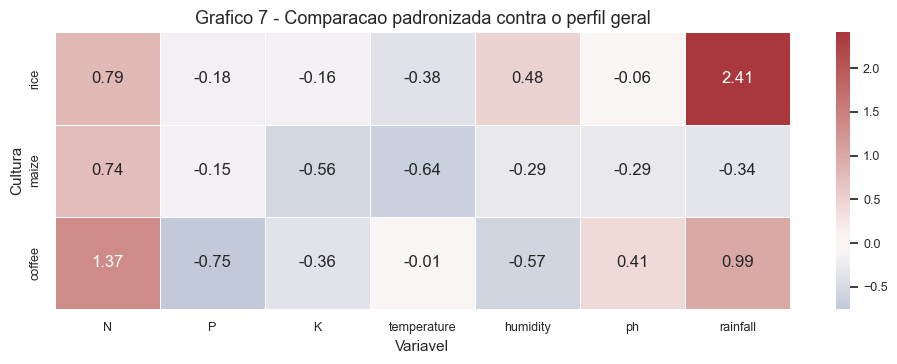

In [13]:

# Grafico 7 - Diferencas padronizadas das culturas escolhidas contra o perfil geral
fig, ax = plt.subplots(figsize=(10, 3.8))
sns.heatmap(dif_padronizada, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.4, ax=ax)
ax.set_title("Grafico 7 - Comparacao padronizada contra o perfil geral")
ax.set_xlabel("Variavel")
ax.set_ylabel("Cultura")
plt.tight_layout()
plt.show()


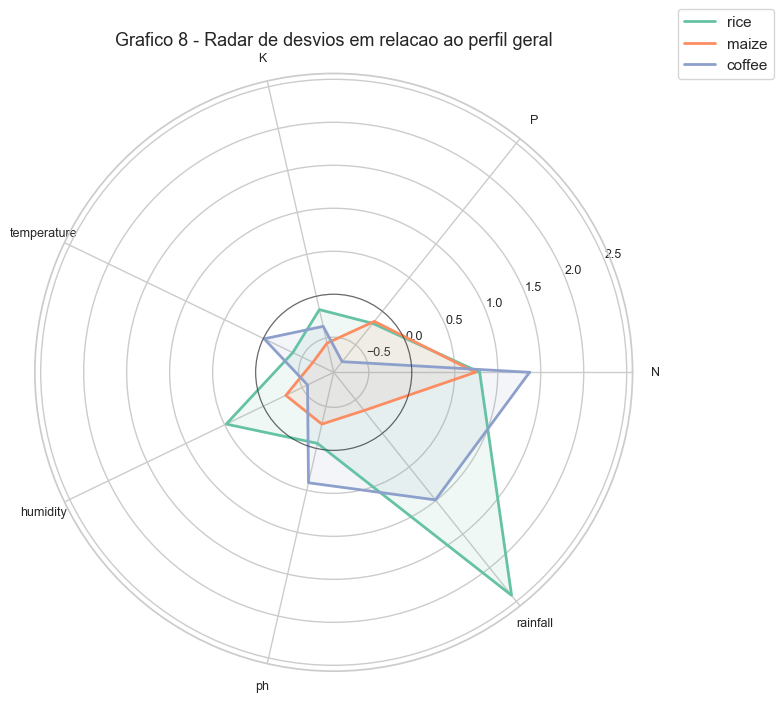

In [14]:

# Grafico 8 - Perfil radial padronizado das culturas escolhidas
radar_cols = FEATURES
angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
for cultura, row in dif_padronizada.iterrows():
    values = row[radar_cols].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=cultura)
    ax.fill(angles, values, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_cols)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_title("Grafico 8 - Radar de desvios em relacao ao perfil geral", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.12))
plt.tight_layout()
plt.show()


In [15]:

nomes_pt = {"rice": "arroz", "maize": "milho", "coffee": "cafe"}
variaveis_pt = {
    "N": "nitrogenio",
    "P": "fosforo",
    "K": "potassio",
    "temperature": "temperatura",
    "humidity": "umidade",
    "ph": "pH",
    "rainfall": "precipitacao",
}

linhas = []
for cultura in culturas_escolhidas:
    desvios = dif_padronizada.loc[cultura]
    acima = desvios.sort_values(ascending=False).head(3)
    abaixo = desvios.sort_values(ascending=True).head(3)
    acima_txt = ", ".join([f"{variaveis_pt[col]} ({val:+.2f} dp)" for col, val in acima.items()])
    abaixo_txt = ", ".join([f"{variaveis_pt[col]} ({val:+.2f} dp)" for col, val in abaixo.items()])
    linhas.append(f"- **{nomes_pt[cultura]} ({cultura})**: acima do perfil geral principalmente em {acima_txt}; abaixo principalmente em {abaixo_txt}.")

texto = "\n".join(linhas)
display(Markdown(f"""
### Comparacao das tres culturas escolhidas

{texto}

Esses desvios mostram que a recomendacao nao depende de uma variavel isolada. O arroz, por exemplo, tende a se associar mais a umidade e chuva elevadas; o milho fica mais proximo de um perfil intermediario em varias dimensoes; e o cafe se destaca por niveis maiores de nitrogenio e por um regime de chuva acima da media geral.
"""))



### Comparacao das tres culturas escolhidas

- **arroz (rice)**: acima do perfil geral principalmente em precipitacao (+2.41 dp), nitrogenio (+0.79 dp), umidade (+0.48 dp); abaixo principalmente em temperatura (-0.38 dp), fosforo (-0.18 dp), potassio (-0.16 dp).
- **milho (maize)**: acima do perfil geral principalmente em nitrogenio (+0.74 dp), fosforo (-0.15 dp), umidade (-0.29 dp); abaixo principalmente em temperatura (-0.64 dp), potassio (-0.56 dp), precipitacao (-0.34 dp).
- **cafe (coffee)**: acima do perfil geral principalmente em nitrogenio (+1.37 dp), precipitacao (+0.99 dp), pH (+0.41 dp); abaixo principalmente em fosforo (-0.75 dp), umidade (-0.57 dp), potassio (-0.36 dp).

Esses desvios mostram que a recomendacao nao depende de uma variavel isolada. O arroz, por exemplo, tende a se associar mais a umidade e chuva elevadas; o milho fica mais proximo de um perfil intermediario em varias dimensoes; e o cafe se destaca por niveis maiores de nitrogenio e por um regime de chuva acima da media geral.



## 5. Modelagem preditiva

O problema e de **classificacao multiclasse**, pois cada linha deve ser associada a uma das culturas possiveis. Foram seguidas boas praticas basicas de Machine Learning:

- separacao treino/teste com estratificacao para preservar a proporcao das culturas;
- uso de `Pipeline` para aplicar padronizacao apenas dentro do fluxo de treino nos modelos sensiveis a escala;
- validacao cruzada estratificada no conjunto de treino;
- avaliacao final em conjunto de teste separado;
- comparacao por acuracia, acuracia balanceada, precisao macro, recall macro e F1 macro.

As metricas macro sao importantes porque tratam todas as classes com o mesmo peso, mesmo quando houver diferencas de quantidade entre classes.


In [16]:

X = df[FEATURES].copy()
y = df["label"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste: {X_test.shape[0]} registros")
print(f"Classes no treino: {y_train.nunique()}")
print(f"Classes no teste: {y_test.nunique()}")


Treino: 1760 registros
Teste: 440 registros
Classes no treino: 22
Classes no teste: 22


In [17]:

modelos = {
    "Regressao Logistica": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE)),
    ]),
    "Arvore de Decisao": Pipeline([
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=None)),
    ]),
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
}

resultados = []
modelos_ajustados = {}

for nome, modelo in modelos.items():
    cv_scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        error_score="raise",
    )
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average="macro", zero_division=0)

    resultados.append({
        "modelo": nome,
        "accuracy_cv_media": cv_scores["test_accuracy"].mean(),
        "accuracy_cv_dp": cv_scores["test_accuracy"].std(),
        "f1_macro_cv_media": cv_scores["test_f1_macro"].mean(),
        "f1_macro_cv_dp": cv_scores["test_f1_macro"].std(),
        "accuracy_teste": accuracy_score(y_test, pred),
        "balanced_accuracy_teste": balanced_accuracy_score(y_test, pred),
        "precision_macro_teste": precision,
        "recall_macro_teste": recall,
        "f1_macro_teste": f1,
    })
    modelos_ajustados[nome] = modelo

resultados_df = pd.DataFrame(resultados).sort_values("f1_macro_teste", ascending=False).reset_index(drop=True)
display(resultados_df.round(4))


,modelo,accuracy_cv_media,accuracy_cv_dp,f1_macro_cv_media,f1_macro_cv_dp,accuracy_teste,balanced_accuracy_teste,precision_macro_teste,recall_macro_teste,f1_macro_teste
0,Random Forest,0.9938,0.0055,0.9937,0.0056,0.9932,0.9932,0.9935,0.9932,0.9932
1,SVM RBF,0.9824,0.0049,0.9822,0.0049,0.9886,0.9886,0.9896,0.9886,0.9887
2,Arvore de Decisao,0.9852,0.0068,0.9852,0.0068,0.9795,0.9795,0.9806,0.9795,0.9794
3,KNN,0.9653,0.0121,0.9650,0.0124,0.9795,0.9795,0.9804,0.9795,0.9793
4,Regressao Logistica,0.9682,0.0066,0.9678,0.0068,0.9727,0.9727,0.9740,0.9727,0.9725


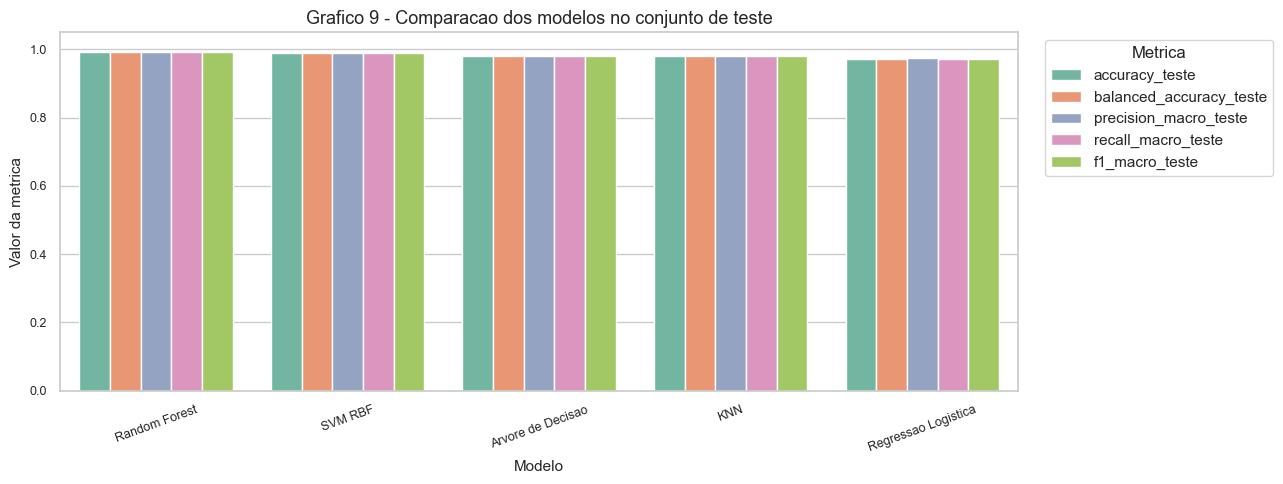

In [18]:

# Grafico 9 - Comparacao das metricas finais no teste
metricas_plot = ["accuracy_teste", "balanced_accuracy_teste", "precision_macro_teste", "recall_macro_teste", "f1_macro_teste"]
plot_df = resultados_df.melt(id_vars="modelo", value_vars=metricas_plot, var_name="metrica", value_name="valor")

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=plot_df, x="modelo", y="valor", hue="metrica", ax=ax)
ax.set_title("Grafico 9 - Comparacao dos modelos no conjunto de teste")
ax.set_xlabel("Modelo")
ax.set_ylabel("Valor da metrica")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Metrica", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Melhor modelo pelo F1 macro no teste: Random Forest

Relatorio de classificacao do melhor modelo:

              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        20
      banana      1.000     1.000     1.000        20
   blackgram      1.000     0.950     0.974        20
    chickpea      1.000     1.000     1.000        20
     coconut      1.000     1.000     1.000        20
      coffee      1.000     1.000     1.000        20
      cotton      1.000     1.000     1.000        20
      grapes      1.000     1.000     1.000        20
        jute      0.952     1.000     0.976        20
 kidneybeans      1.000     1.000     1.000        20
      lentil      1.000     0.950     0.974        20
       maize      0.952     1.000     0.976        20
       mango      1.000     1.000     1.000        20
   mothbeans      0.952     1.000     0.976        20
    mungbean      1.000     1.000     1.000        20
   muskmelon      1.000     1.000   

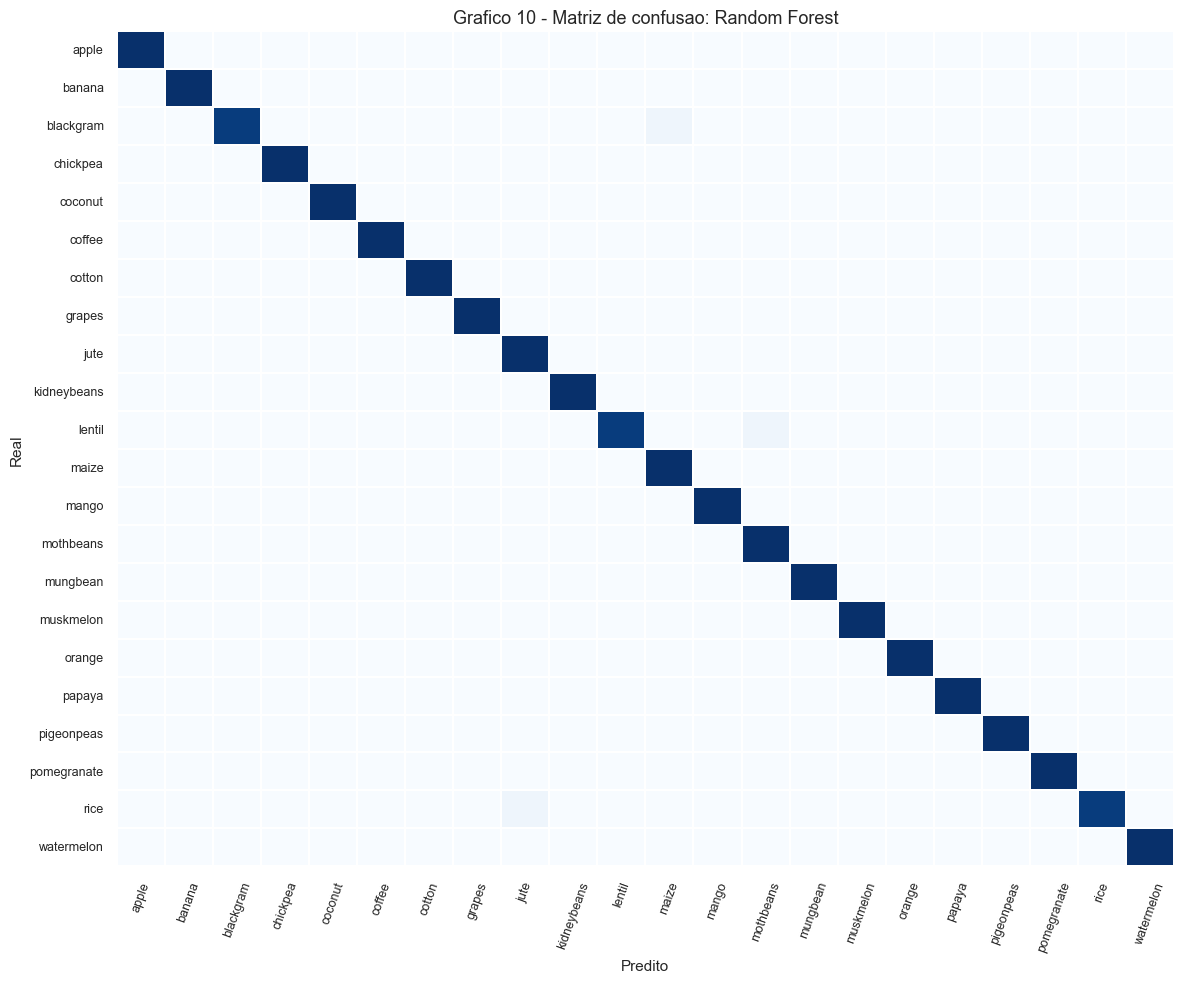

In [19]:

melhor_nome = resultados_df.loc[0, "modelo"]
melhor_modelo = modelos_ajustados[melhor_nome]
melhor_pred = melhor_modelo.predict(X_test)
classes = sorted(y.unique())

print(f"Melhor modelo pelo F1 macro no teste: {melhor_nome}")
print("\nRelatorio de classificacao do melhor modelo:\n")
print(classification_report(y_test, melhor_pred, digits=3, zero_division=0))

cm = confusion_matrix(y_test, melhor_pred, labels=classes)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues", cbar=False, xticklabels=classes, yticklabels=classes, linewidths=0.2, ax=ax)
ax.set_title(f"Grafico 10 - Matriz de confusao: {melhor_nome}")
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.tick_params(axis="x", rotation=70)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()


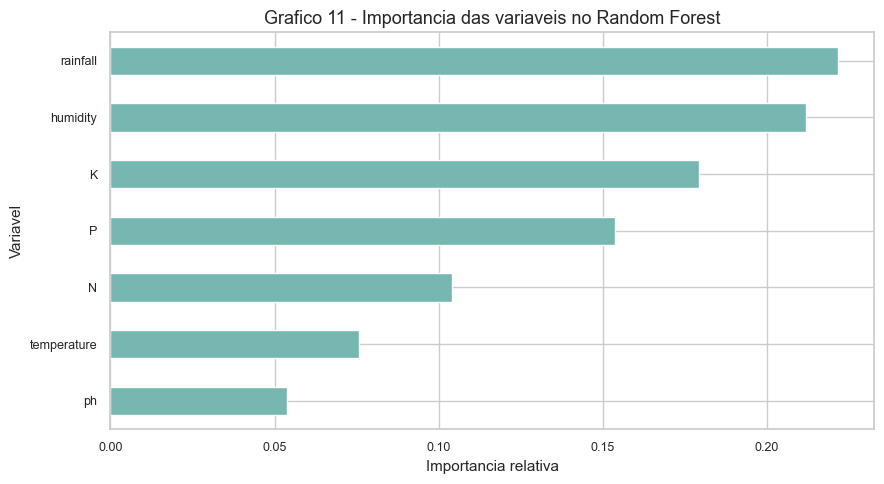

,importancia
rainfall,0.2215
humidity,0.2119
K,0.1792
P,0.1537
N,0.1039
temperature,0.0758
ph,0.0539


In [20]:

# Grafico 11 - Importancia de variaveis no Random Forest
rf_model = modelos_ajustados["Random Forest"].named_steps["model"]
importancias = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
importancias.plot(kind="barh", ax=ax, color="#76b7b2")
ax.set_title("Grafico 11 - Importancia das variaveis no Random Forest")
ax.set_xlabel("Importancia relativa")
ax.set_ylabel("Variavel")
plt.tight_layout()
plt.show()

display(importancias.sort_values(ascending=False).to_frame("importancia").round(4))



## 6. Conclusoes e limitacoes

A base apresenta padroes bem definidos entre nutrientes, clima e cultura recomendada. Isso explica por que modelos supervisionados conseguem bom desempenho: as classes possuem combinacoes relativamente distintas de N, P, K, temperatura, umidade, pH e chuva.

A comparacao entre arroz, milho e cafe reforca que o perfil ideal e especifico por cultura. O arroz tende a depender de umidade e chuva mais altas; o milho aparece mais perto de uma faixa intermediaria; e o cafe combina maior nitrogenio com chuva acima da media geral.

O principal ponto forte do trabalho e a combinacao de EDA, perfil estatistico por cultura e comparacao entre modelos. As principais limitacoes sao: a base parece controlada e balanceada, nao inclui variaveis economicas ou regionais, nao considera sazonalidade, pragas, tipo de solo detalhado ou custo de insumos, e os modelos foram avaliados apenas com a divisao disponivel nesta base. Em uso real, seria necessario validar com dados locais e recentes antes de recomendar plantio.


In [21]:

melhor_linha = resultados_df.iloc[0]
segundo_linha = resultados_df.iloc[1]

display(Markdown(f"""
### Sintese final dos modelos

- O melhor modelo foi **{melhor_linha['modelo']}**, com **F1 macro de {melhor_linha['f1_macro_teste']:.3f}** e **acuracia de {melhor_linha['accuracy_teste']:.3f}** no teste.
- O segundo melhor foi **{segundo_linha['modelo']}**, com **F1 macro de {segundo_linha['f1_macro_teste']:.3f}**.
- Como a base e multiclasse e bem balanceada, acuracia e F1 macro ficaram proximas; ainda assim, o F1 macro foi usado como criterio principal por avaliar o desempenho medio entre todas as culturas.
- Para melhorar o projeto, seria interessante testar ajuste de hiperparametros, validacao externa com dados de outra regiao e interpretabilidade mais profunda por cultura.
"""))



### Sintese final dos modelos

- O melhor modelo foi **Random Forest**, com **F1 macro de 0.993** e **acuracia de 0.993** no teste.
- O segundo melhor foi **SVM RBF**, com **F1 macro de 0.989**.
- Como a base e multiclasse e bem balanceada, acuracia e F1 macro ficaram proximas; ainda assim, o F1 macro foi usado como criterio principal por avaliar o desempenho medio entre todas as culturas.
- Para melhorar o projeto, seria interessante testar ajuste de hiperparametros, validacao externa com dados de outra regiao e interpretabilidade mais profunda por cultura.
